# Fuente: Playstore_reviews.csv

| **Variable**           | **Definition**                                                                 |
|------------------------|--------------------------------------------------------------------------------|
|Package_name              |Nombre de la aplicación móvil (categórico                                                |
|Review            | Comentario sobre la aplicación móvil (categórico)                                                  |
|Polarity              | Variable de clase (0 o 1), siendo 0 un comentario negativo y 1, positivo (categórico numérico)                                                    |

En este trabajo se desarrolla un sistema de clasificación automática de comentarios escritos en Google Play, con el objetivo de identificar si tienen una connotación positiva o negativa. Para ello, se utilizarán técnicas de procesamiento de texto y algoritmos de clasificación como Naive Bayes.

## 1.Carga del conjunto de datos

In [21]:
# LIBRERIAS NECESARIAS
import pandas as pd
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from IPython.display import display
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [22]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv"
df = pd.read_csv(url)

In [23]:
df.shape 

(891, 3)

In [24]:
df.columns.tolist()

['package_name', 'review', 'polarity']

In [25]:
pd.set_option('display.max_colwidth', None)
df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offline. i mean for some people like me it's a big pressure to be seen online like you need to response on every message or else you be called seenzone only. if only i wanna do on facebook is to read on my newsfeed and just wanna response on message i want to. pls reconsidered my review. i tried to turn off chat but still can see me as online.,0
1,com.facebook.katana,"messenger issues ever since the last update, initial received messages don't get pushed to the messenger app and you don't get notification in the facebook app or messenger app. you open the facebook app and happen to see you have a message. you have to click the icon and it opens messenger. subsequent messages go through messenger app, unless you close the chat head... then you start over with no notification and having to go through the facebook app.",0
2,com.facebook.katana,profile any time my wife or anybody has more than one post and i view them it would take me to there profile so that i can view them all at once. now when i try to view them it tells me that the page that i requested is not available. i've restarted my phone i even cleard the cache and i've uninstalled and reinstalled the app and it is still doing it. please fix it thank you,0
3,com.facebook.katana,the new features suck for those of us who don't have a working back button can you guys make the videos able to be slid to the left to exit the video. as i have to force close facebook to exit,0
4,com.facebook.katana,"forced reload on uploading pic on replying comment last night i tried to reply a comment by uploading a photo from my phone. when i press on the button to select photos the app automatically goes back to the main page. on other occasions, i could enter to my gallery to select my image but as soon as i selected an image and press done, the program, again, forced reload and suddenly go back to the main page. please fix this and i will change my rating. thank you.",0


## Paso 2: Estudio de variables y su contenido

En este conjunto de datos contamos con tres variables: dos que actúan como predictoras y una que representa la etiqueta de salida, la cual es de tipo dicotómico. De las variables predictoras, únicamente nos interesa el contenido del comentario, ya que es el que determina si la opinión expresada es positiva o negativa. Por esta razón, la columna que indica el nombre de la aplicación (package_name) no aporta valor al análisis y debe ser eliminada.

- Objetivo: Dejar el texto limpio y eliminar información irrelevante.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   package_name  891 non-null    object
 1   review        891 non-null    object
 2   polarity      891 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.0+ KB


Procedemos a eliminar la columna package_name porque no aporta valor a la predicción del sentimiento y posibles nulos.

In [27]:
# Eliminar columnas no útiles
df = df.drop(columns=['package_name'])

In [28]:
# Eliminar filas vacías
df = df.dropna()

In [29]:
## Limpiar texto: minúsculas y espacios
df['review'] = df['review'].str.strip().str.lower()


In [30]:
# Resultados limpios
df.head()

,review,polarity
0,privacy at least put some option appear offline. i mean for some people like me it's a big pressure to be seen online like you need to response on every message or else you be called seenzone only. if only i wanna do on facebook is to read on my newsfeed and just wanna response on message i want to. pls reconsidered my review. i tried to turn off chat but still can see me as online.,0
1,"messenger issues ever since the last update, initial received messages don't get pushed to the messenger app and you don't get notification in the facebook app or messenger app. you open the facebook app and happen to see you have a message. you have to click the icon and it opens messenger. subsequent messages go through messenger app, unless you close the chat head... then you start over with no notification and having to go through the facebook app.",0
2,profile any time my wife or anybody has more than one post and i view them it would take me to there profile so that i can view them all at once. now when i try to view them it tells me that the page that i requested is not available. i've restarted my phone i even cleard the cache and i've uninstalled and reinstalled the app and it is still doing it. please fix it thank you,0
3,the new features suck for those of us who don't have a working back button can you guys make the videos able to be slid to the left to exit the video. as i have to force close facebook to exit,0
4,"forced reload on uploading pic on replying comment last night i tried to reply a comment by uploading a photo from my phone. when i press on the button to select photos the app automatically goes back to the main page. on other occasions, i could enter to my gallery to select my image but as soon as i selected an image and press done, the program, again, forced reload and suddenly go back to the main page. please fix this and i will change my rating. thank you.",0


Conversión del texto a formato numérico

In [31]:
# Separar variableS
X = df['review']
y = df['polarity']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Vectorización del texto
vec_model = CountVectorizer(stop_words='english')
X_train_vec = vec_model.fit_transform(X_train).toarray()
X_test_vec = vec_model.transform(X_test).toarray()



# Mostrar información estructural
display(f"Tamaño de X_train: {X_train.shape}")
display(f"Tamaño de X_test: {X_test.shape}")
display(f"Shape de X_train_vec: {X_train_vec.shape}")
display(f"Shape de X_test_vec: {X_test_vec.shape}")

# Mostrar distribución de clases
display("Distribución de clases en y_train:")
display(y_train.value_counts())

display("Distribución de clases en y_test:")
display(y_test.value_counts())



'Tamaño de X_train: (712,)'

'Tamaño de X_test: (179,)'

'Shape de X_train_vec: (712, 3310)'

'Shape de X_test_vec: (179, 3310)'

'Distribución de clases en y_train:'

polarity
0    458
1    254
Name: count, dtype: int64

'Distribución de clases en y_test:'

polarity
0    126
1     53
Name: count, dtype: int64

Tras realizar la limpieza del dataset, se eliminaron columnas innecesarias y valores nulos, dejando únicamente el texto del comentario como variable relevante para el análisis. Posteriormente, se dividió el conjunto de datos en entrenamiento (80%) y prueba (20%) de forma aleatoria y estratificada, lo que permitió conservar la proporción de clases (comentarios positivos y negativos) en ambos subconjuntos.

La distribución de la variable objetivo (polarity) muestra un ligero desequilibrio: hay más comentarios negativos que positivos, aunque no de forma extrema. Esto indica que el modelo podría aprender sin requerir técnicas de balanceo en esta etapa.

Además, al transformar los comentarios en una matriz numérica mediante CountVectorizer, se identificaron 3310 palabras únicas que servirán como características para entrenar los modelos. Esta transformación convierte los textos en vectores que reflejan la frecuencia de cada palabra en los comentarios, lo que permite aplicar algoritmos de clasificación de forma efectiva.

En resumen, los datos están preparados correctamente para comenzar el entrenamiento de modelos

Paso 3: Construccion naive bayes

In [32]:
#ELECCION DEL MODELO 
# Entrenar y evaluar varios modelos Naive Bayes

# MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train)
acc_mnb = accuracy_score(y_test, mnb.predict(X_test_vec))

# BernoulliNB
bnb = BernoulliNB()
bnb.fit(X_train_vec, y_train)
acc_bnb = accuracy_score(y_test, bnb.predict(X_test_vec))

# GaussianNB 
gnb = GaussianNB()
acc_gnb = accuracy_score(y_test, gnb.fit(X_train_vec, y_train).predict(X_test_vec))

# Mostrar resultados en una tabla
resultados = pd.DataFrame({
    "Modelo": ["MultinomialNB", "BernoulliNB", "GaussianNB"],
    "Accuracy": [acc_mnb, acc_bnb, acc_gnb]
})
display(resultados)

,Modelo,Accuracy
0,MultinomialNB,0.815642
1,BernoulliNB,0.770950
2,GaussianNB,0.804469


El modelo MultinomialNB es la mejor opción para este tipo de tarea de clasificación de texto. 

Naturaleza del texto vectorizado (recuento de palabras)

Al usar CountVectorizer, el texto se convierte en una matriz de recuento de palabras ([0, 1, 2, 3,...]).

Este tipo de datos sigue una distribución multinomial, y justamente MultinomialNB está diseñado para trabajar con conteos discretos como esos.

In [33]:
#Entrenar un modelo Naive Bayes (MultinomialNB)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# Predicciones y evaluación

y_train_pred = nb_model.predict(X_train_vec)
y_test_pred = nb_model.predict(X_test_vec)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_accuracy, test_accuracy

(0.9606741573033708, 0.8156424581005587)

In [34]:
# Evaluación detallada del modelo
report = classification_report(y_test, y_test_pred, output_dict=False)
cm = confusion_matrix(y_test, y_test_pred)

# Mostrar reporte
print(report)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       126
           1       0.73      0.60      0.66        53

    accuracy                           0.82       179
   macro avg       0.79      0.75      0.77       179
weighted avg       0.81      0.82      0.81       179



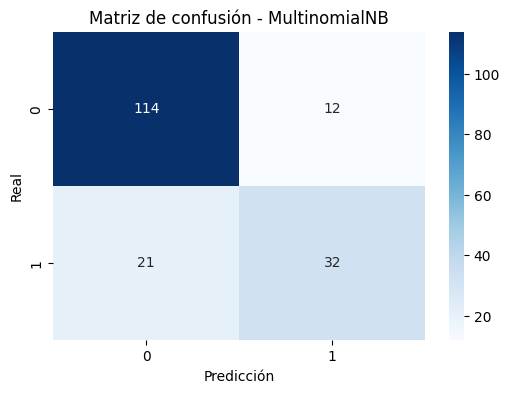

In [35]:
# Visualizar matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_)
plt.title('Matriz de confusión - MultinomialNB')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [36]:
# Ejemplos de predicciones individuales
for i in range(5):
    actual = y_test.iloc[i]
    predicted = y_test_pred[i]
    text = X_test.iloc[i][:150]  # Mostrar hasta 150 caracteres
    print(f"Texto: '{text}...'\nActual: {actual} | Predicho: {predicted} | Correcto: {actual == predicted}")
    print("-" * 50)


Texto: 'love/hate has bug and security issues. i tried to report that facebook and google plus have security issues and it wouldn't allow me to do so! well i ...'
Actual: 0 | Predicho: 0 | Correcto: True
--------------------------------------------------
Texto: 'whatsapp i use this app now that blackberry messenger has basically gone away. my friends & family live all over the world. this really helps keep us ...'
Actual: 1 | Predicho: 0 | Correcto: False
--------------------------------------------------
Texto: 'usefully verry  nice app...'
Actual: 1 | Predicho: 1 | Correcto: True
--------------------------------------------------
Texto: 'fonts why in the heck is this thing analysing my fonts??? not really quick browsing when i have to wait 5minutes for the fonts to load. are you asking...'
Actual: 0 | Predicho: 0 | Correcto: True
--------------------------------------------------
Texto: 'app doesn't work after latest upgrade the facebook app refuses to work on my mobile data (3g) aft

### Conclusión del Paso 3: Evaluación de MultinomialNB

El modelo `MultinomialNB` alcanzó un 96% de precisión en entrenamiento y un 82% en prueba, mostrando un buen desempeño general con indicios leves de sobreajuste. 

Analizando el `classification_report`, observamos que:

- El modelo identifica muy bien los comentarios **negativos** (clase 0), con un `recall` de 90% y un `f1-score` de 0.87.
- En cambio, tiene más dificultad con los comentarios **positivos** (clase 1), alcanzando un `recall` de solo 60% y un `f1-score` de 0.66.

Este comportamiento se confirma con los ejemplos de predicción: el modelo acierta en la mayoría de los negativos pero falla más al detectar positivos, lo que indica cierto **desequilibrio en la clasificación**.

A pesar de ello, `MultinomialNB` demuestra ser el modelo más adecuado para continuar el proyecto por su buen rendimiento y eficiencia computacional.


### Paso 4: Optimiza el modelo anterior 

,precision,recall,f1-score,support
0,0.88,0.83,0.85,126.0
1,0.64,0.74,0.68,53.0
accuracy,0.80,0.80,0.80,0.8
macro avg,0.76,0.78,0.77,179.0
weighted avg,0.81,0.80,0.80,179.0


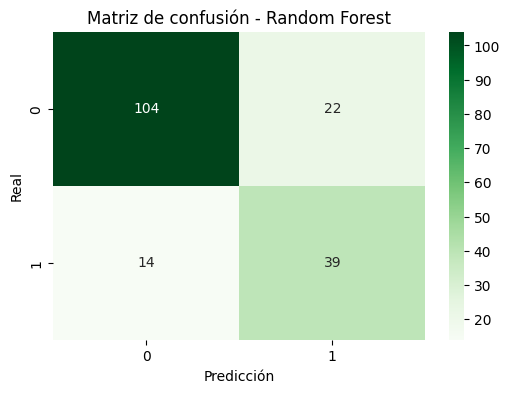

In [ ]:
# Entrenamiento
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vec, y_train)

# Predicciones
y_test_pred_rf = rf_model.predict(X_test_vec)

# Generar el reporte como diccionario
reporte_dict = classification_report(y_test, y_test_pred_rf, output_dict=True)

# Convertir a DataFrame y redondear
reporte_df = pd.DataFrame(reporte_dict).transpose().round(2)

# Mostrar tabla
display(reporte_df)

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.title('Matriz de confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


 # Interpretación del modelo Random Forest


El modelo de clasificación Random Forest mostró un rendimiento general sólido al aplicarse sobre el conjunto de datos vectorizado. Obtuvo una precisión global (accuracy) del 80 %, lo que indica que 8 de cada 10 predicciones fueron correctas.

Al desglosar el desempeño por clases, se observa un mejor rendimiento al clasificar opiniones negativas (clase 0), donde alcanzó una precisión del 88 % y un F1-score de 0.85. Esto significa que el modelo es muy eficaz al identificar correctamente las reseñas negativas.

Por el contrario, al clasificar opiniones positivas (clase 1), el modelo tuvo un rendimiento más bajo: alcanzó una precisión del 64 % y un F1-score de 0.68. Esto indica que tiende a confundir algunas opiniones positivas como negativas, especialmente en casos donde el lenguaje no es tan explícito.

La matriz de confusión confirma esta tendencia: se observan 22 falsos positivos (opiniones negativas clasificadas incorrectamente como positivas) y 14 falsos negativos (positivas clasificadas como negativas). Aun así, logró detectar correctamente 39 de las 53 reseñas positivas reales.

En resumen, el modelo Random Forest muestra buen rendimiento general, especialmente con reseñas negativas, aunque aún tiene margen de mejora en la clasificación de reseñas positivas.



### Comparacion entre modelo Rndom Forest y MultinomialNB

In [38]:

# Crear diccionario con los resultados
comparacion = {
    "Métrica": [
        "Accuracy",
        "F1-score (Clase 0)",
        "F1-score (Clase 1)",
        "Precision (Clase 0)",
        "Precision (Clase 1)",
        "Recall (Clase 0)",
        "Recall (Clase 1)",
        "Macro avg F1-score",
        "Weighted avg F1-score"
    ],
    "MultinomialNB": [
        0.815,
        0.87,
        0.66,
        0.84,
        0.73,
        0.90,
        0.60,
        0.77,
        0.81
    ],
    "Random Forest": [
        0.800,
        0.85,
        0.68,
        0.88,
        0.64,
        0.83,
        0.74,
        0.77,
        0.80
    ]
}

# Convertir a DataFrame
df_comparacion = pd.DataFrame(comparacion)

# Mostrar tabla
display(df_comparacion)


,Métrica,MultinomialNB,Random Forest
0,Accuracy,0.815,0.80
1,F1-score (Clase 0),0.870,0.85
2,F1-score (Clase 1),0.660,0.68
3,Precision (Clase 0),0.840,0.88
4,Precision (Clase 1),0.730,0.64
5,Recall (Clase 0),0.900,0.83
6,Recall (Clase 1),0.600,0.74
7,Macro avg F1-score,0.770,0.77
8,Weighted avg F1-score,0.810,0.80


Ambos modelos ofrecen resultados muy similares en términos de métricas globales. MultinomialNB obtiene una ligera ventaja en accuracy general y un mejor desempeño en la clasificación de opiniones negativas. Sin embargo, Random Forest mejora levemente el desempeño con la clase positiva, con un F1-score de 0.68 frente al 0.66 de MultinomialNB.

Esto sugiere que:

Si se busca velocidad y simplicidad, MultinomialNB sigue siendo la mejor opción.

Si se prioriza una mejor detección de opiniones positivas, Random Forest puede ser una buena alternativa

 Observaciones rápidas:
 
MultinomialNB tiene mejor precisión en la clase 1 (positiva), pero peor recall.

Random Forest identifica mejor las reseñas positivas (mayor recall para clase 1).

Ambos tienen idéntico macro F1-score (0.77), por lo que su balance general entre clases es similar.

## Paso 5: Guardar el modelo 

In [39]:
# Asegurarse de que existe la carpeta de modelos
os.makedirs("modelos", exist_ok=True)

# Guardar el modelo y el vectorizador
joblib.dump(nb_model, "modelos/modelo_multinomialNB.pkl")
joblib.dump(vec_model, "modelos/vectorizador_count.pkl")
print("Modelo y vectorizador guardados en la carpeta 'modelos'")

Modelo y vectorizador guardados en la carpeta 'modelos'


## Paso 6: Explora otras alternativas (Logistic Regression)

,precision,recall,f1-score,support
0,0.913793,0.841270,0.876033,126.000000
1,0.682540,0.811321,0.741379,53.000000
accuracy,0.832402,0.832402,0.832402,0.832402
macro avg,0.798166,0.826295,0.808706,179.000000
weighted avg,0.845321,0.832402,0.836164,179.000000


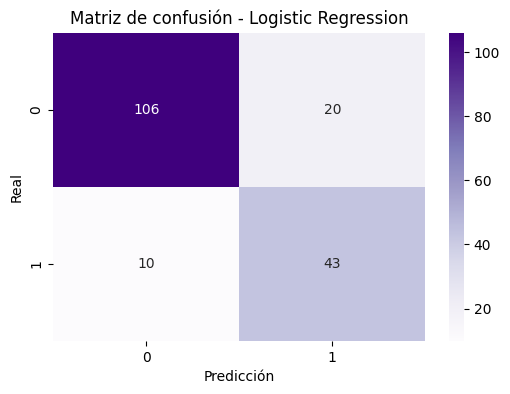

In [40]:

# Entrenar modelo
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train_vec, y_train)

# Predicción y evaluación
y_pred_log = log_model.predict(X_test_vec)

# Reporte de clasificación en formato dict
report_log = classification_report(y_test, y_pred_log, output_dict=True)
df_report_log = pd.DataFrame(report_log).transpose()
display(df_report_log)

# Matriz de confusión
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Purples',
            xticklabels=log_model.classes_,
            yticklabels=log_model.classes_)
plt.title('Matriz de confusión - Logistic Regression')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


Después de evaluar múltiples modelos, se concluye que `MultinomialNB` es el más adecuado para esta tarea de clasificación de texto, ya que ofrece un equilibrio entre precisión y eficiencia. Sin embargo, modelos como `Random Forest` y `Logistic Regression` también muestran resultados competitivos y podrían considerarse en contextos donde se priorice la precisión sobre la velocidad.


## Conclusión del Proyecto

El objetivo principal de este proyecto fue desarrollar un sistema de clasificación automática de comentarios en Google Play, capaz de identificar si un texto refleja una opinión positiva o negativa. Para ello, se aplicaron técnicas de procesamiento de lenguaje natural (NLP) combinadas con modelos de aprendizaje automático supervisado.

Después de limpiar y preparar los datos, se procedió a transformar los textos mediante la vectorización con CountVectorizer, eliminando palabras vacías en inglés y convirtiendo el texto en representaciones numéricas utilizables por los modelos.

En la etapa de modelado, se probaron tres variantes de Naive Bayes (MultinomialNB, BernoulliNB y GaussianNB). De estas, el modelo Multinomial Naive Bayes demostró ser el más adecuado para el tipo de datos con los que se trabajaba, ya que los datos de texto vectorizados con conteo se ajustan mejor a su supuesto estadístico. Este modelo logró una precisión del 81.5 %, destacándose por su buen desempeño al clasificar correctamente comentarios negativos. Sin embargo, mostró cierta dificultad al detectar correctamente los comentarios positivos (recall de solo 60 %).

Posteriormente, se entrenó un modelo Random Forest para tratar de mejorar los resultados. Este modelo logró una precisión global del 80 %, con una ligera mejora en la clasificación de opiniones positivas (recall de 74 %), aunque con un leve descenso en la identificación de opiniones negativas.

Finalmente, se evaluó una tercera alternativa: Regresión Logística, que también logró resultados competitivos con un rendimiento similar al de Naive Bayes y Random Forest. La elección final del modelo puede depender del equilibrio que se quiera priorizar: velocidad y simplicidad (Naive Bayes), o un mejor desempeño sobre la clase minoritaria (Random Forest).

 Conclusión final
A lo largo del proyecto se demostró que es totalmente viable construir un sistema automático capaz de identificar la polaridad (positiva o negativa) de comentarios escritos en lenguaje natural. Aunque ningún modelo es perfecto, los resultados obtenidos —con precisiones entre 80 % y 82 %— son sólidos y útiles para tareas reales de monitoreo de opiniones o soporte al cliente.
